# CIS5450 Project
Group: Group_7

By: Max Eldabbas, Anthony Lam, Yechezkel Rothman

TA: Shailesh Sridhar

## IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
%%capture
!apt update
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!echo '{"username":"anthonylamx","key":"a1660e57a76c07c9c89c3190c831f9c9"}' > ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d openfoodfacts/world-food-facts
!ls
!unzip world-food-facts.zip
from google.colab import drive
drive.mount('/content/drive')
!mkdir -p /content/drive/MyDrive/kaggle_datasets
!cp -r ./*.tsv /content/drive/MyDrive/kaggle_datasets/

Dataset URL: https://www.kaggle.com/datasets/openfoodfacts/world-food-facts
License(s): DbCL-1.0
sample_data  world-food-facts.zip
Archive:  world-food-facts.zip
  inflating: en.openfoodfacts.org.products.tsv  
Mounted at /content/drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!cp /content/drive/MyDrive/kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download -d openfoodfacts/world-food-facts

Dataset URL: https://www.kaggle.com/datasets/openfoodfacts/world-food-facts
License(s): DbCL-1.0
world-food-facts.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip /content/world-food-facts.zip

Archive:  /content/world-food-facts.zip
replace en.openfoodfacts.org.products.tsv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: en.openfoodfacts.org.products.tsv  


# Data Preprocessing, Exploration, Cleaning, Feature Engineering

In [ ]:
# Read in Open Food Facts
open_food_facts = pd.read_csv('en.openfoodfacts.org.products.tsv', sep='\t', on_bad_lines= 'skip')

open_food_facts.head()

<ipython-input-9-9e93b91790c7>:2: DtypeWarning: Columns (0,3,5,19,20,24,25,26,27,28,36,37,38,39,48) have mixed types. Specify dtype option on import or set low_memory=False.
  open_food_facts = pd.read_csv('en.openfoodfacts.org.products.tsv', sep='\t', on_bad_lines= 'skip')


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,product_name,generic_name,quantity,...,fruits-vegetables-nuts_100g,fruits-vegetables-nuts-estimate_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,nutrition-score-fr_100g,nutrition-score-uk_100g,glycemic-index_100g,water-hardness_100g
0,3087,http://world-en.openfoodfacts.org/product/0000...,openfoodfacts-contributors,1474103866,2016-09-17T09:17:46Z,1474103893,2016-09-17T09:18:13Z,Farine de blé noir,NaN,1kg,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4530,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,14.0,14.0,NaN,NaN
2,4559,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489069957,2017-03-09T14:32:37Z,1489069957,2017-03-09T14:32:37Z,Peanuts,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN
3,16087,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489055731,2017-03-09T10:35:31Z,1489055731,2017-03-09T10:35:31Z,Organic Salted Nut Mix,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,12.0,NaN,NaN
4,16094,http://world-en.openfoodfacts.org/product/0000...,usda-ndb-import,1489055653,2017-03-09T10:34:13Z,1489055653,2017-03-09T10:34:13Z,Organic Polenta,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Data Inspection / Understanding the Data

In [ ]:
for col in open_food_facts.columns:
  print(col)

code
url
creator
created_t
created_datetime
last_modified_t
last_modified_datetime
product_name
generic_name
quantity
packaging
packaging_tags
brands
brands_tags
categories
categories_tags
categories_en
origins
origins_tags
manufacturing_places
manufacturing_places_tags
labels
labels_tags
labels_en
emb_codes
emb_codes_tags
first_packaging_code_geo
cities
cities_tags
purchase_places
stores
countries
countries_tags
countries_en
ingredients_text
allergens
allergens_en
traces
traces_tags
traces_en
serving_size
no_nutriments
additives_n
additives
additives_tags
additives_en
ingredients_from_palm_oil_n
ingredients_from_palm_oil
ingredients_from_palm_oil_tags
ingredients_that_may_be_from_palm_oil_n
ingredients_that_may_be_from_palm_oil
ingredients_that_may_be_from_palm_oil_tags
nutrition_grade_uk
nutrition_grade_fr
pnns_groups_1
pnns_groups_2
states
states_tags
states_en
main_category
main_category_en
image_url
image_small_url
energy_100g
energy-from-fat_100g
fat_100g
saturated-fat_100g
-buty

In [ ]:
open_food_facts.dtypes

,0
code,object
url,object
creator,object
created_t,object
created_datetime,object
...,...
carbon-footprint_100g,float64
nutrition-score-fr_100g,float64
nutrition-score-uk_100g,float64
glycemic-index_100g,float64


In [ ]:
# Checking for missing values, inspect data types, get summary, visualize
print("SHAPE:")
print(open_food_facts.shape)
print()
print("DTYPES:")
print(open_food_facts.info())
print()
print("MISSING VALUES:")
print(open_food_facts.isnull().sum())

missing_50 = (open_food_facts.isnull().mean() > 0.5).sum()
print(f"Number of columns with more than 50% missing values: {missing_50}")

print()
print("SUMMARY:")
print(open_food_facts.describe())

SHAPE:
(356027, 163)

DTYPES:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356027 entries, 0 to 356026
Columns: 163 entries, code to water-hardness_100g
dtypes: float64(107), object(56)
memory usage: 442.8+ MB
None

MISSING VALUES:
code                           26
url                            26
creator                         3
created_t                       3
created_datetime               10
                            ...  
carbon-footprint_100g      355749
nutrition-score-fr_100g    101171
nutrition-score-uk_100g    101171
glycemic-index_100g        356027
water-hardness_100g        356027
Length: 163, dtype: int64
Number of columns with more than 50% missing values: 129

SUMMARY:
       no_nutriments    additives_n  ingredients_from_palm_oil_n  \
count            0.0  283867.000000                283867.000000   
mean             NaN       1.876851                     0.023430   
std              NaN       2.501022                     0.153094   
min              NaN    

In [ ]:
open_food_facts.nunique()

,0
code,355839
url,356001
creator,3890
created_t,224812
created_datetime,224752
...,...
carbon-footprint_100g,204
nutrition-score-fr_100g,55
nutrition-score-uk_100g,55
glycemic-index_100g,0


# Cleaning the data

---



In [ ]:
# Drop unwanted columns

cols_to_drop = [
    'code', 'url', 'creator', 'created_t', 'last_modified_t', 'image_url', 'image_small_url',
    'brands_tags', 'categories', 'categories_tags', 'countries_tags',
    'labels', 'labels_tags', 'labels_en', 'origins', 'origins_tags',
    'manufacturing_places', 'manufacturing_places_tags', 'emb_codes', 'emb_codes_tags',
    'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places', 'stores',
    'states', 'states_tags', 'states_en', 'main_category_en'
]

open_food_facts.drop(columns=cols_to_drop, inplace=True)

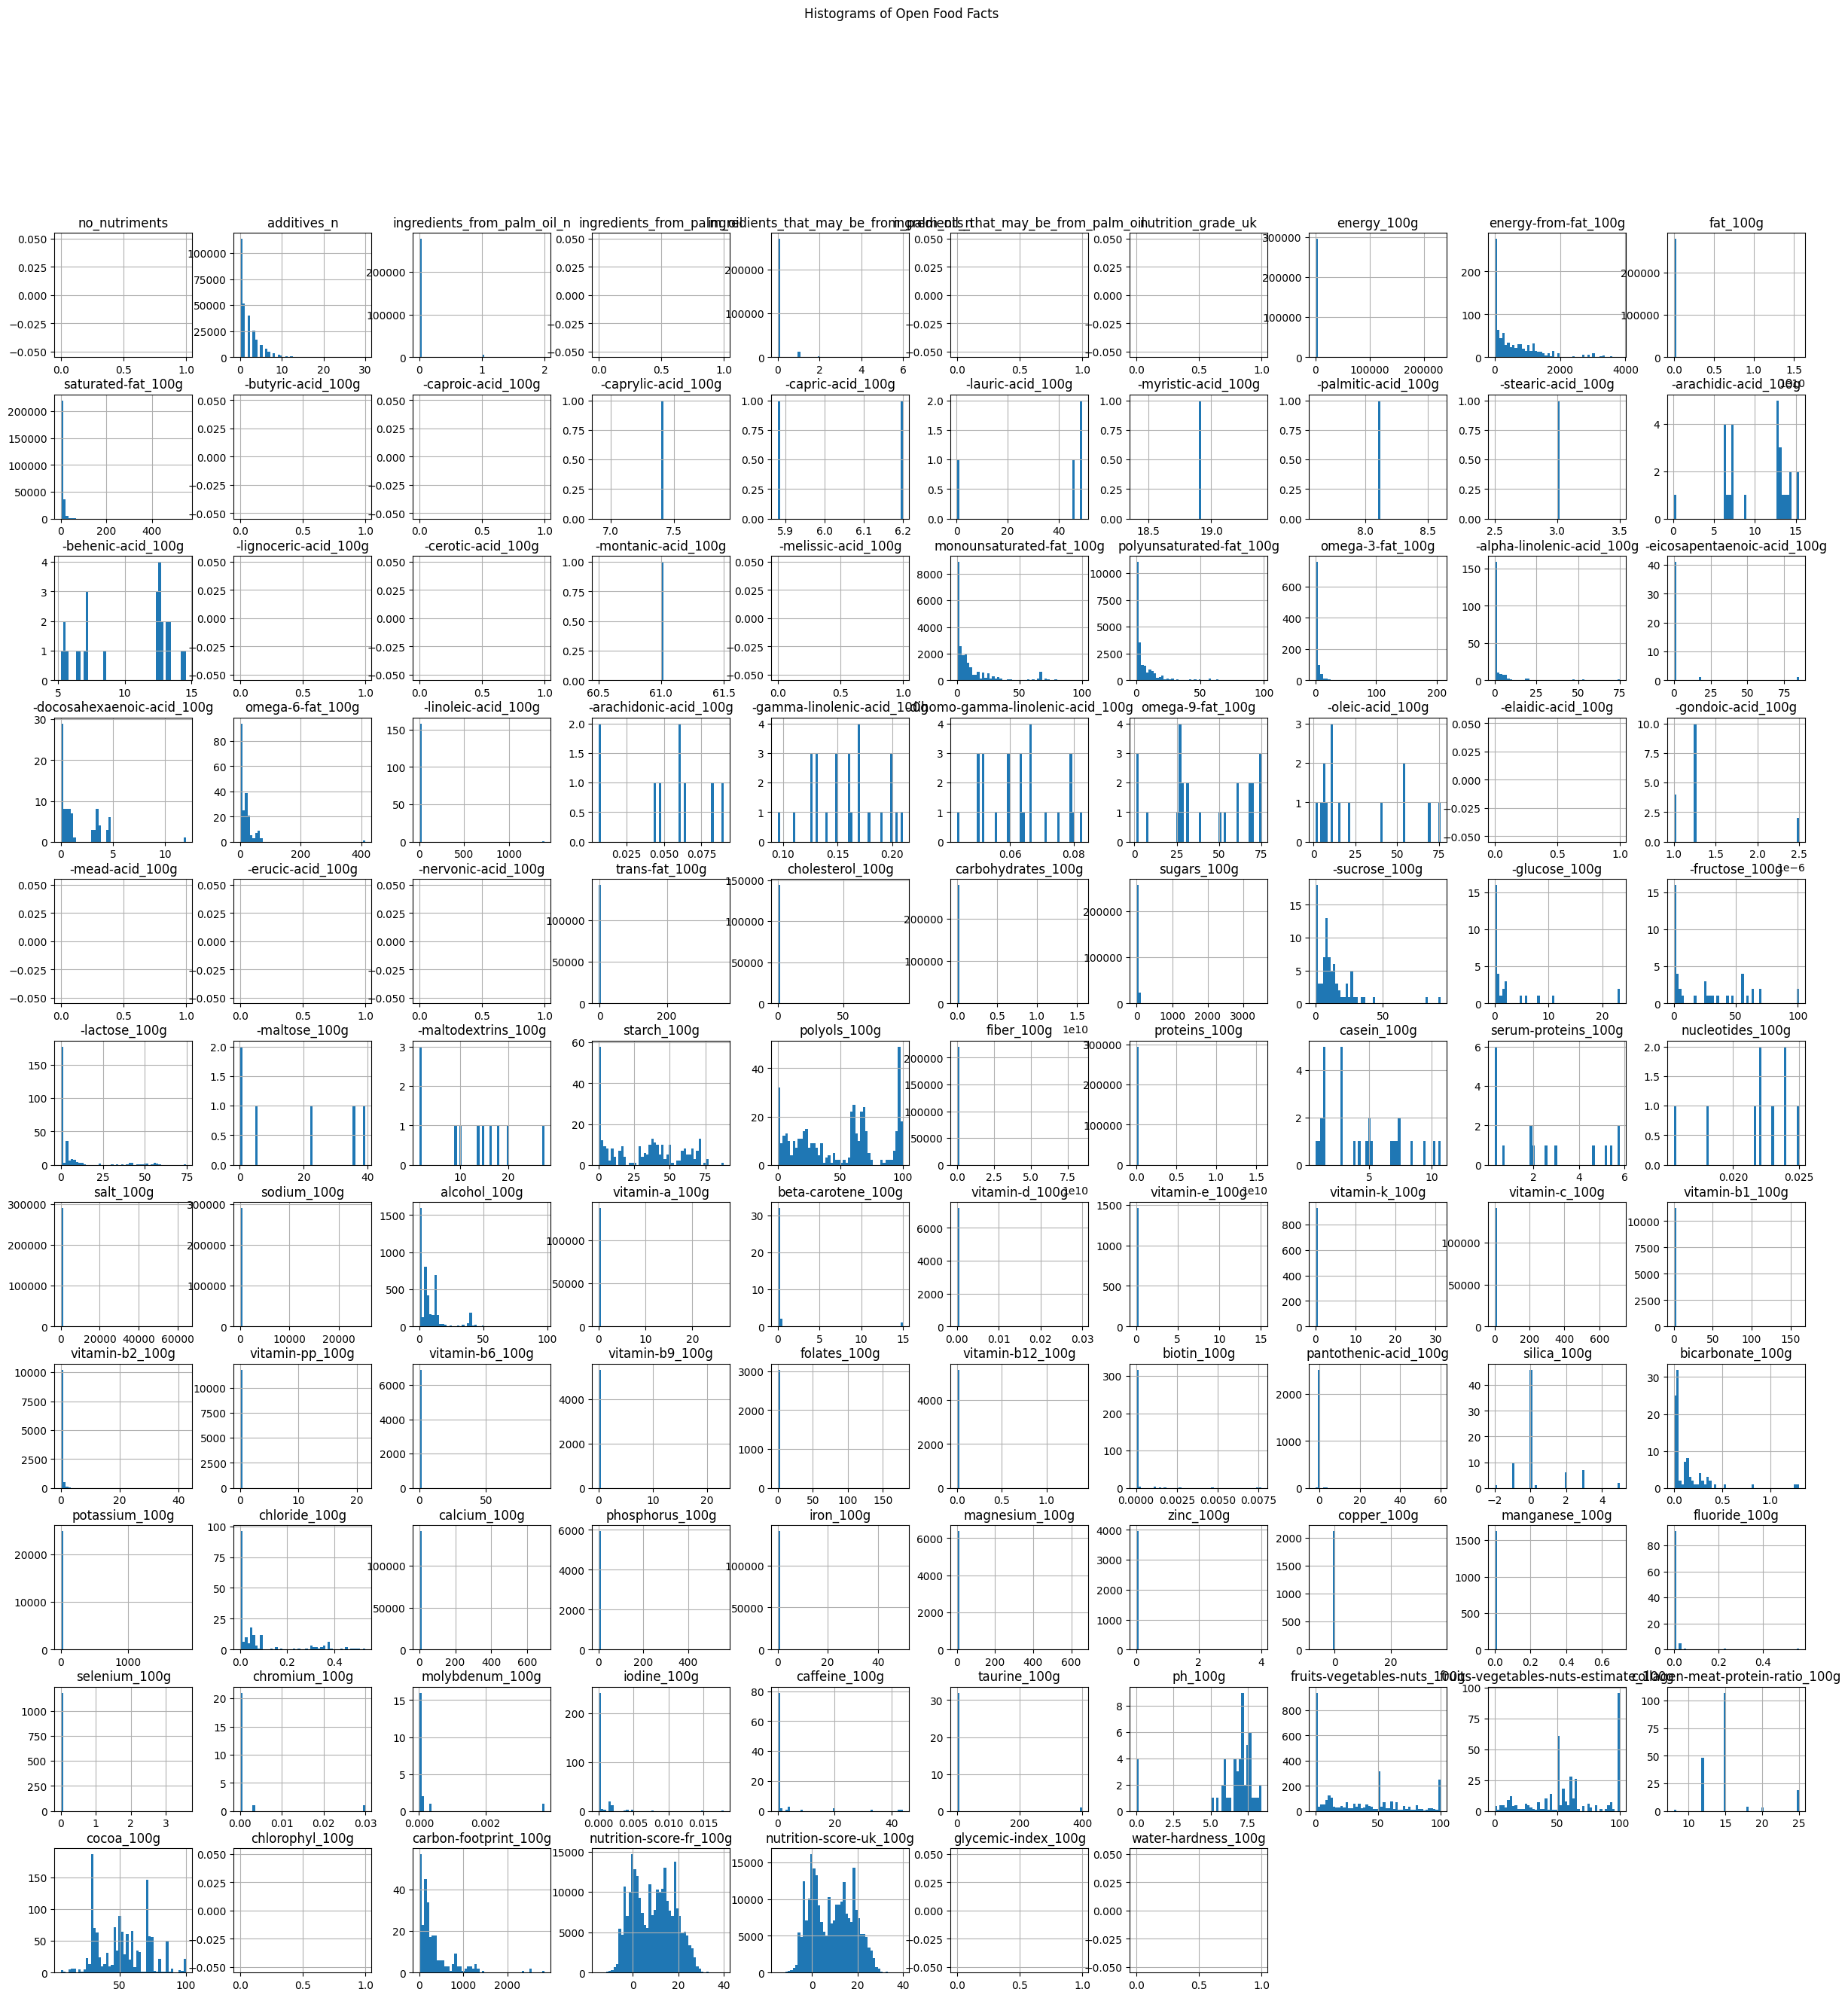

In [ ]:
# Visualizing Distributions
open_food_facts.hist(figsize = (30, 30), bins = 50)
plt.suptitle('Histograms of Open Food Facts')
plt.show()

In [ ]:
# Get rid of columns that have more than 75% of missing values
open_food_facts = open_food_facts.dropna(thresh=len(open_food_facts) * 0.25, axis=1)

In [ ]:
# Drop duplicate rows
open_food_facts = open_food_facts.drop_duplicates()

In [ ]:
# Replace missing values for all columns to be consistent
def fill_missing_values(df):
    for col in df.columns:
      if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
      else:
        df[col] = df[col].fillna(0)
    return df

fill_missing_values(open_food_facts)

open_food_facts.head()

,created_datetime,last_modified_datetime,product_name,quantity,packaging,packaging_tags,brands,categories_en,countries,countries_en,...,fiber_100g,proteins_100g,salt_100g,sodium_100g,vitamin-a_100g,vitamin-c_100g,calcium_100g,iron_100g,nutrition-score-fr_100g,nutrition-score-uk_100g
0,2016-09-17T09:17:46Z,2016-09-17T09:18:13Z,Farine de blé noir,1kg,Unknown,Unknown,Ferme t'y R'nao,Unknown,en:FR,France,...,0.0,0.00,0.00000,0.000,0.0,0.0000,0.000,0.00000,0.0,0.0
1,2017-03-09T14:32:37Z,2017-03-09T14:32:37Z,Banana Chips Sweetened (Whole),Unknown,Unknown,Unknown,Unknown,Unknown,US,United States,...,3.6,3.57,0.00000,0.000,0.0,0.0214,0.000,0.00129,14.0,14.0
2,2017-03-09T14:32:37Z,2017-03-09T14:32:37Z,Peanuts,Unknown,Unknown,Unknown,Torn & Glasser,Unknown,US,United States,...,7.1,17.86,0.63500,0.250,0.0,0.0000,0.071,0.00129,0.0,0.0
3,2017-03-09T10:35:31Z,2017-03-09T10:35:31Z,Organic Salted Nut Mix,Unknown,Unknown,Unknown,Grizzlies,Unknown,US,United States,...,7.1,17.86,1.22428,0.482,0.0,0.0000,0.143,0.00514,12.0,12.0
4,2017-03-09T10:34:13Z,2017-03-09T10:34:13Z,Organic Polenta,Unknown,Unknown,Unknown,Bob's Red Mill,Unknown,US,United States,...,5.7,8.57,0.00000,0.000,0.0,0.0000,0.000,0.00000,0.0,0.0


In [ ]:
# Convert date time columns
open_food_facts['created_datetime'] = pd.to_datetime(open_food_facts['created_datetime'], errors = 'coerce')
open_food_facts['last_modified_datetime'] = pd.to_datetime(open_food_facts['last_modified_datetime'], errors = 'coerce')

open_food_facts['created_datetime'] = open_food_facts.dropna(subset=['created_datetime'])['created_datetime']

open_food_facts.info()

<class 'pandas.core.frame.DataFrame'>
Index: 355447 entries, 0 to 356026
Data columns (total 39 columns):
 #   Column                                   Non-Null Count   Dtype              
---  ------                                   --------------   -----              
 0   created_datetime                         355420 non-null  datetime64[ns, UTC]
 1   last_modified_datetime                   355421 non-null  datetime64[ns, UTC]
 2   product_name                             355447 non-null  object             
 3   quantity                                 355447 non-null  object             
 4   packaging                                355447 non-null  object             
 5   packaging_tags                           355447 non-null  object             
 6   brands                                   355447 non-null  object             
 7   categories_en                            355447 non-null  object             
 8   countries                                355447 non-null  o

## Feature Engineering

In [ ]:
# Feature Engineering

# Date time features
open_food_facts['created_year'] = open_food_facts['created_datetime'].dt.year
open_food_facts['created_month'] = open_food_facts['created_datetime'].dt.month
open_food_facts['created_day'] = open_food_facts['created_datetime'].dt.day
open_food_facts['last_modified_year'] = open_food_facts['last_modified_datetime'].dt.year
open_food_facts['last_modified_month'] = open_food_facts['last_modified_datetime'].dt.month
open_food_facts['last_modified_day'] = open_food_facts['last_modified_datetime'].dt.day

# Custom health score feature calculated by dividing the sum of unhealthy nutrients by the sum of healthy ingredients
open_food_facts['health_score'] = (open_food_facts['proteins_100g'] + open_food_facts["fiber_100g"] + open_food_facts["vitamin-a_100g"] + open_food_facts["vitamin-c_100g"] + open_food_facts["calcium_100g"] + open_food_facts["iron_100g"]) / (open_food_facts["saturated-fat_100g"] + open_food_facts["trans-fat_100g"] + open_food_facts["sugars_100g"] + open_food_facts["sodium_100g"]).replace(0, np.nan)

# Scale the health score to be out of 100 (while also cutting out the outliers)
open_food_facts['health_score_log'] = np.log1p(open_food_facts['health_score'])
open_food_facts['health_score_scaled'] = (open_food_facts['health_score_log'] - open_food_facts['health_score_log'].min()) / (open_food_facts['health_score_log'].max() - open_food_facts['health_score_log'].min()) * 100

# open_food_facts['health_score'] = open_food_facts['health_score'].fillna(0)
# open_food_facts['health_score_scaled'] = open_food_facts['health_score_scaled'].fillna(0)
open_food_facts = open_food_facts.dropna(subset=['health_score_scaled'])

# Custom nutrient ratios
open_food_facts['fat_to_energy_ratio'] = open_food_facts['fat_100g'] / open_food_facts['energy_100g'].replace(0, np.nan)
open_food_facts['sugar_to_carbs_ratio'] = open_food_facts['sugars_100g'] / open_food_facts['carbohydrates_100g'].replace(0, np.nan)
open_food_facts['protein_to_carbs_ratio'] = open_food_facts['proteins_100g'] / open_food_facts['carbohydrates_100g'].replace(0, np.nan)

# Find number of ingredients in each product
open_food_facts['num_ingredients'] = open_food_facts['ingredients_text'].str.count(',') + 1

# See if there is palm oil in the product
open_food_facts['has_palm_oils'] = (open_food_facts['ingredients_from_palm_oil_n'] > 0).astype(int)
open_food_facts['has_possible_palm_oils'] = (open_food_facts['ingredients_that_may_be_from_palm_oil_n'] > 0).astype(int)

# Find number of additives
open_food_facts['num_additives'] = open_food_facts['additives_n'].fillna(0).astype(int)

open_food_facts.head(5)

/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
<ipython-input-20-7f2bb5c2b828>:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  open_food_facts['fat_to_energy_ratio'] = open_food_facts['fat_100g'] / open_food_facts['energy_100g'].replace(0, np.nan)
<ipython-input-20-7f2bb5c2b828>:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  open_food_facts['sugar_to_carbs_ratio'] = open_food_f

,created_datetime,last_modified_datetime,product_name,quantity,packaging,packaging_tags,brands,categories_en,countries,countries_en,...,health_score,health_score_log,health_score_scaled,fat_to_energy_ratio,sugar_to_carbs_ratio,protein_to_carbs_ratio,num_ingredients,has_palm_oils,has_possible_palm_oils,num_additives
1,2017-03-09 14:32:37+00:00,2017-03-09 14:32:37+00:00,Banana Chips Sweetened (Whole),Unknown,Unknown,Unknown,Unknown,Unknown,US,United States,...,0.167818,0.155137,4.123288,0.012737,0.222274,0.055530,4,0,0,0
2,2017-03-09 14:32:37+00:00,2017-03-09 14:32:37+00:00,Peanuts,Unknown,Unknown,Unknown,Torn & Glasser,Unknown,US,United States,...,1.382236,0.868039,7.162253,0.009201,0.294185,0.294185,13,0,0,0
3,2017-03-09 10:35:31+00:00,2017-03-09 10:35:31+00:00,Organic Salted Nut Mix,Unknown,Unknown,Unknown,Grizzlies,Unknown,US,United States,...,2.667673,1.299557,9.001731,0.022496,0.199888,1.000000,5,0,0,0
5,2017-03-09 10:34:11+00:00,2017-03-09 10:34:11+00:00,Breadshop Honey Gone Nuts Granola,Unknown,Unknown,Unknown,Unfi,Unknown,US,United States,...,1.575146,0.945906,7.494183,0.009452,0.181847,0.212102,9,0,0,0
7,2017-03-09 10:35:11+00:00,2017-03-09 10:35:12+00:00,Organic Muesli,Unknown,Unknown,Unknown,Daddy's Muesli,Unknown,US,United States,...,1.155228,0.767897,6.735363,0.010229,0.270195,0.243211,31,0,0,1


### Correlation Heatmap of Nutritional Features

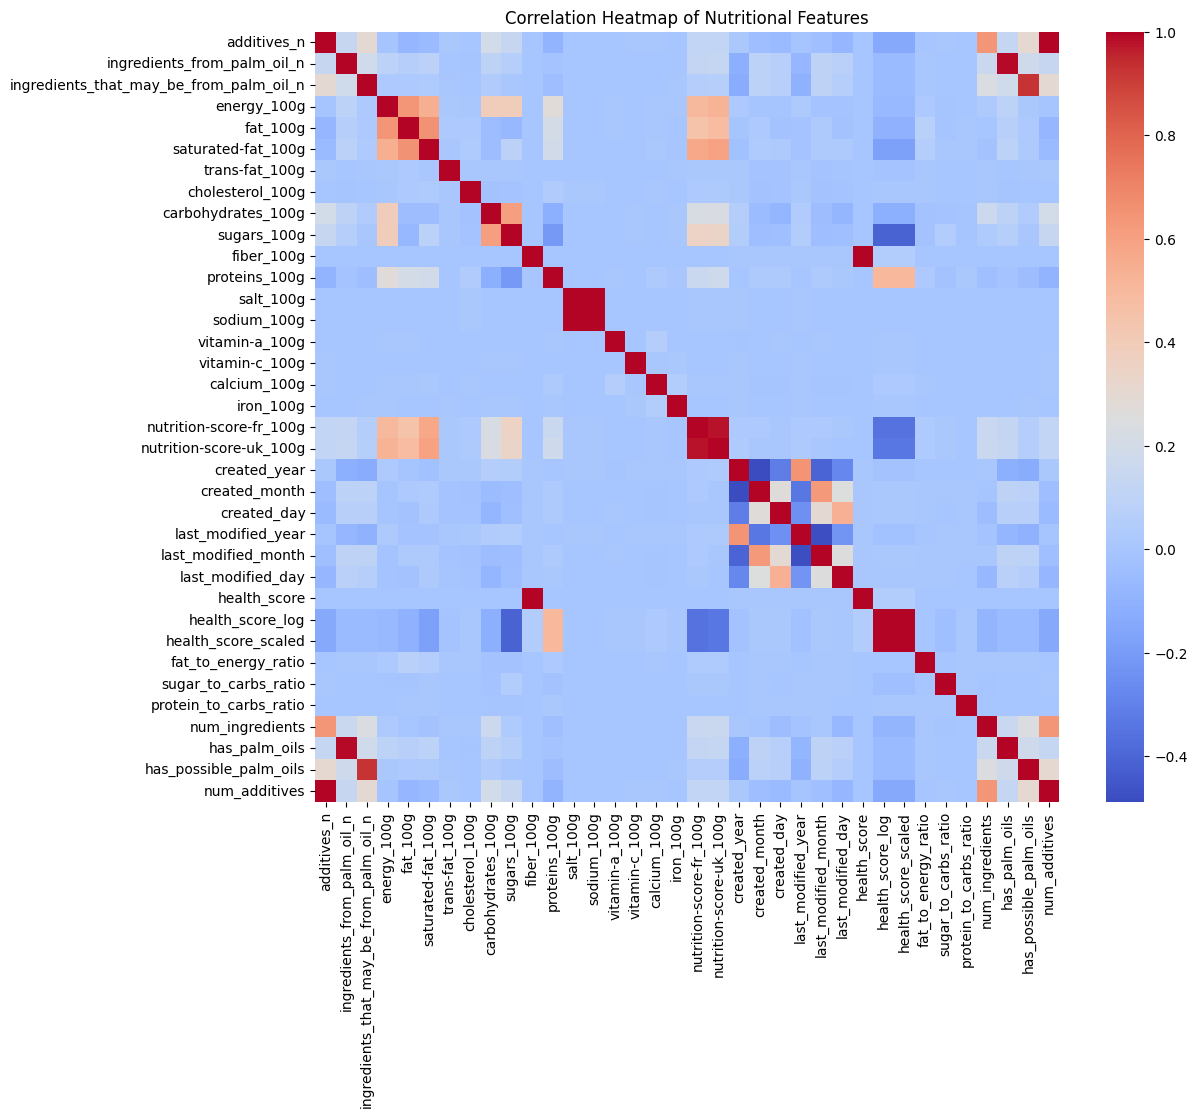

In [ ]:
numeric_cols = open_food_facts.select_dtypes(include = ['float64', 'int64'])

corr_matrix = numeric_cols.corr()

health_score_corr = corr_matrix['health_score_scaled']

exclude_cols = ['health_score', 'health_score_log', 'health_score_scaled', 'created_day', 'created_month', 'created_year', 'last_modified_day', 'last_modified_month', 'last_modified_year']

filtered_health_corr = health_score_corr.drop(labels=exclude_cols).sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot = False, cmap='coolwarm')
plt.title('Correlation Heatmap of Nutritional Features')
plt.show()

### Top 15 Features Most Correlated with Health Score

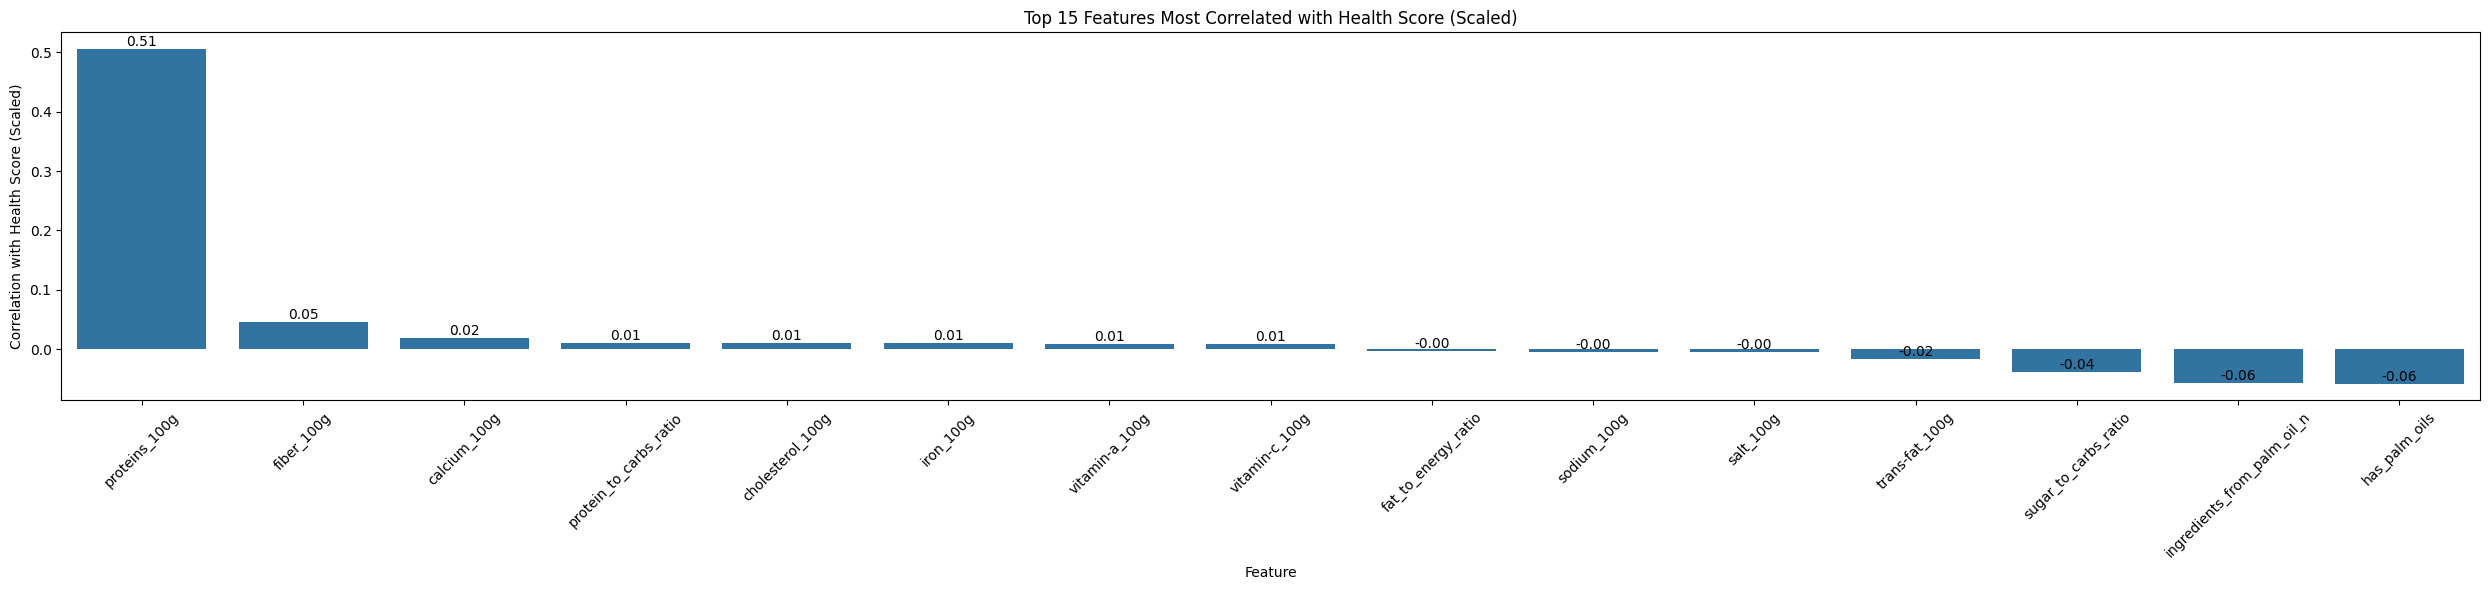

In [ ]:
top_15_features = filtered_health_corr.head(15)

plt.figure(figsize=(25, 6))
sns.barplot(x=top_15_features.index, y=top_15_features.values)
plt.title('Top 15 Features Most Correlated with Health Score (Scaled)')
plt.xlabel('Feature')
plt.ylabel('Correlation with Health Score (Scaled)')
plt.xticks(rotation=45)

for x, y in enumerate(top_15_features.values):
    plt.text(x, y, f'{y:.2f}', color='black', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Health Score Scaled (Raw) at a Glance

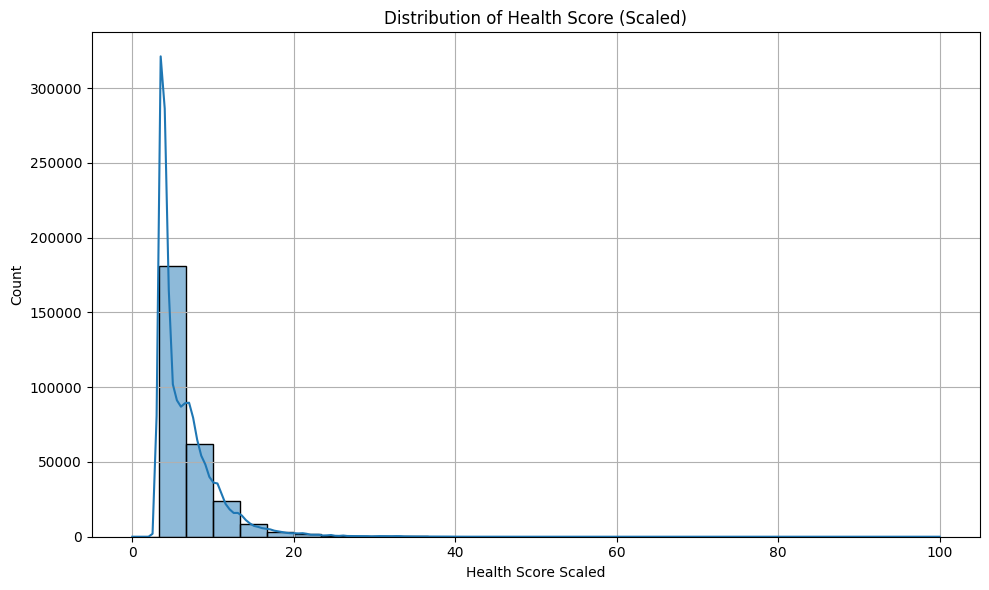

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(open_food_facts['health_score_scaled'], kde=True, bins=30)
plt.title('Distribution of Health Score (Scaled)')
plt.xlabel('Health Score Scaled')
plt.ylabel('Count')
plt.grid(True)
plt.tight_layout()
plt.show()

### Turning Health Score (Scaled) into a Classification Column

In [ ]:
# Binning health score classes by quantile so that all classes of health scores are relative to each other
open_food_facts['health_score_class'] = pd.qcut(open_food_facts['health_score_scaled'], q=3, labels=[0, 1, 2])

In [ ]:
features = ['num_ingredients', 'fat_to_energy_ratio', 'sugar_to_carbs_ratio', 'protein_to_carbs_ratio', 'num_additives', 'has_palm_oils', 'has_possible_palm_oils', 'created_year', 'created_month', 'created_day', 'last_modified_year', 'last_modified_month', 'last_modified_day']

X = open_food_facts[features]
y = open_food_facts['health_score_class']

seed = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = seed)

              precision    recall  f1-score   support

           0       0.90      0.90      0.90     18773
           1       0.81      0.81      0.81     18822
           2       0.88      0.88      0.88     19032

    accuracy                           0.87     56627
   macro avg       0.87      0.87      0.87     56627
weighted avg       0.87      0.87      0.87     56627



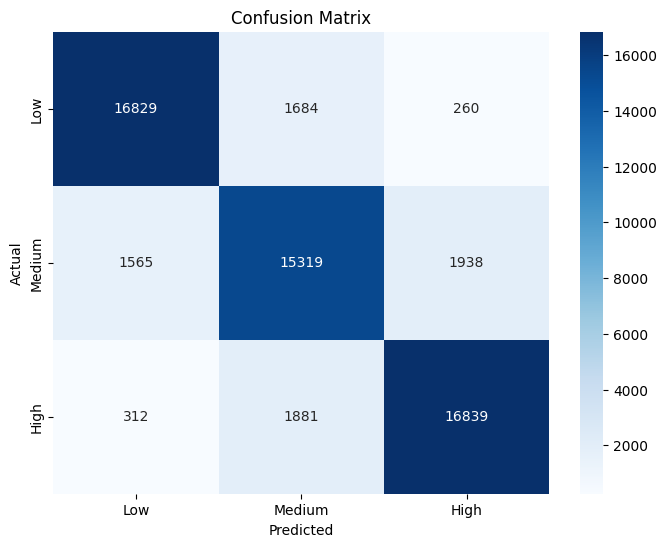

In [ ]:
model = RandomForestClassifier(class_weight='balanced', n_estimators = 120, max_depth = 20, random_state = seed)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print(classification_report(y_test, y_pred))

confusion = confusion_matrix(y_test, y_pred)
labels = ['Low', 'Medium', 'High']
plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', xticklabels = labels, yticklabels = labels)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Judging by the classification report generated, our model is 87% accurate. From the confusion matrix, it predicts health-low foods correctly 16829 times, health-medium foods 15319 times, and health-high foods correctly 16839 times.

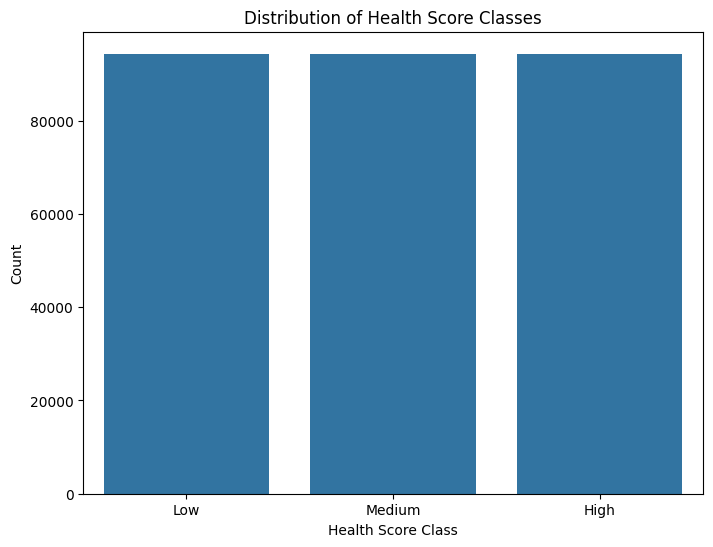

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x = 'health_score_class', data = open_food_facts)
plt.title('Distribution of Health Score Classes')
plt.xlabel('Health Score Class')
plt.ylabel('Count')
plt.xticks([0, 1, 2], ['Low', 'Medium', 'High'])
plt.show()

### Finding Feature Importances

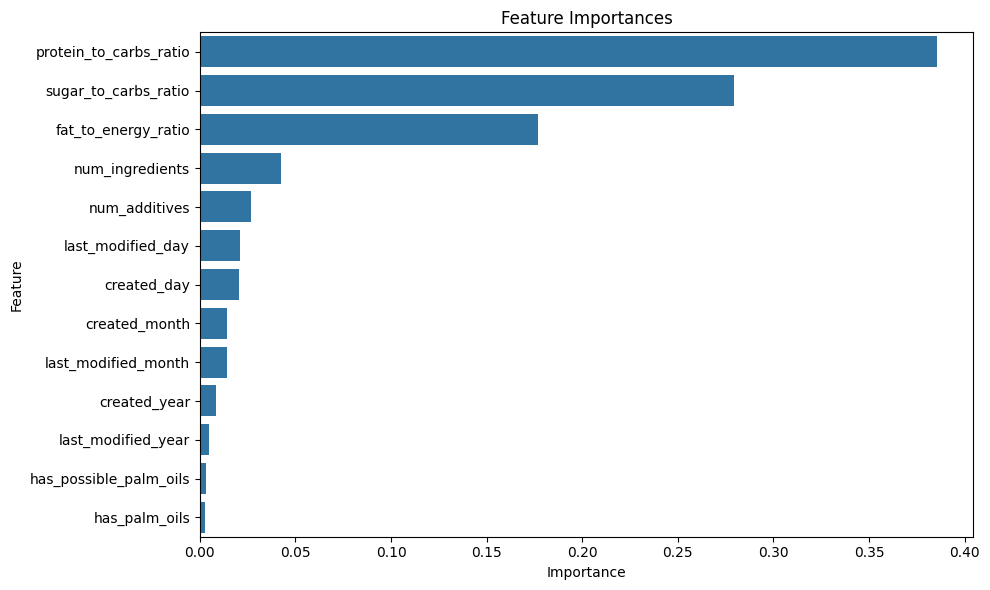

In [ ]:
importances = model.feature_importances_

feature_importances = pd.DataFrame({'Feature': features, 'Importance': importances})

feature_importances = feature_importances.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

## Data Splitting, Regression Modeling, Model Evaluation

Data Splitting

In [ ]:
features = ['num_ingredients', 'fat_to_energy_ratio', 'sugar_to_carbs_ratio',
           'protein_to_carbs_ratio', 'num_additives', 'has_palm_oils',
           'has_possible_palm_oils', 'created_year', 'created_month',
           'created_day', 'last_modified_year', 'last_modified_month',
           'last_modified_day']

In [ ]:
#split the data on the health score using the same features
X = open_food_facts[features]
y = open_food_facts['health_score_scaled']

# Remove any remaining null values in features
X = X.fillna(0)
y = y.fillna(0)

# Split the data with seed 42 and an 80/20 split
seed = 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

Regression Modeling

In [ ]:
# Initialize and train the Random Forest Regressor
regressor = RandomForestRegressor(n_estimators=120, max_depth=20, random_state=seed)
regressor.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, n_estimators=120, random_state=42)

In [ ]:
# Make predictions
y_pred = regressor.predict(X_test)

Model Evaluation

In [ ]:
# Calculate regression metrics
# R-squared Score
r2 = r2_score(y_test, y_pred)

# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Root Mean Squared Error
rmse = np.sqrt(mse)

# Mean Absolute Error
mae = np.mean(np.abs(y_test - y_pred))

In [ ]:
# Print eval metrics
print("Regression Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")

Regression Model Evaluation Metrics:
Mean Squared Error (MSE): 3.3406
Root Mean Squared Error (RMSE): 1.8277
Mean Absolute Error (MAE): 0.7500
R-squared Score: 0.7786


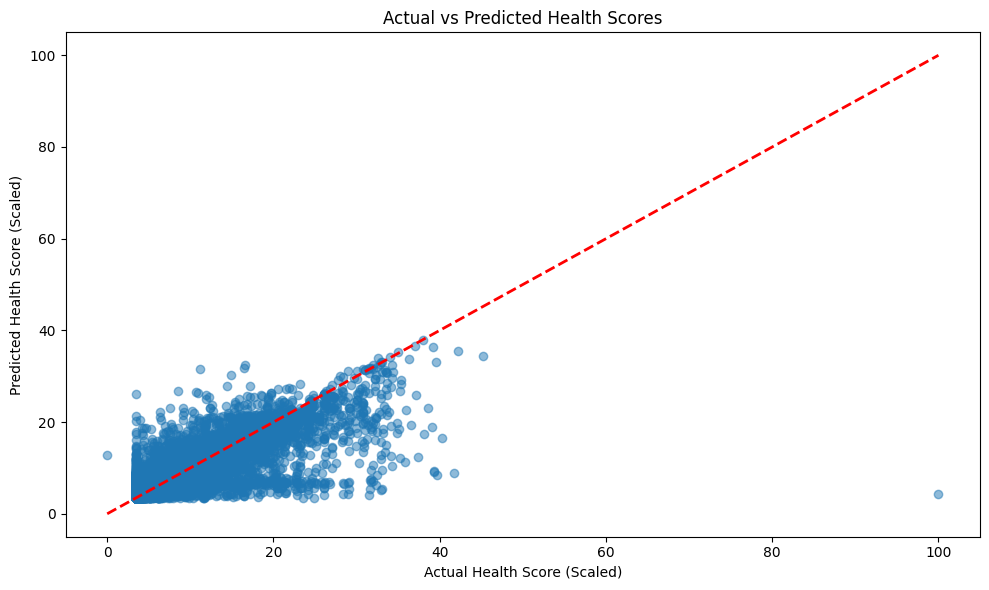

In [ ]:
# plot the actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Health Score (Scaled)')
plt.ylabel('Predicted Health Score (Scaled)')
plt.title('Actual vs Predicted Health Scores')
plt.tight_layout()
plt.show()

Clustering Analysis: Grouping Foods by other Nutritional factors

We can apply K-Means clustering to a other nutritional features, allowing us to identify patterns in food products that may not fit perfectly with our health score classification. We use 2 clusters as found from the elbow method and compare the results visually and statistically.

In [ ]:
#imports
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Select features for clustering
cluster_features = ['energy_100g', 'fat_100g', 'sugars_100g', 'proteins_100g', 'fiber_100g',
                    'sodium_100g', 'vitamin-a_100g', 'vitamin-c_100g', 'calcium_100g', 'iron_100g']
# remove nulls
X_cluster = open_food_facts[cluster_features].dropna()
energy_threshold = X_cluster['energy_100g'].quantile(0.99)
X_cluster_filtered = X_cluster[X_cluster['energy_100g'] <= energy_threshold]

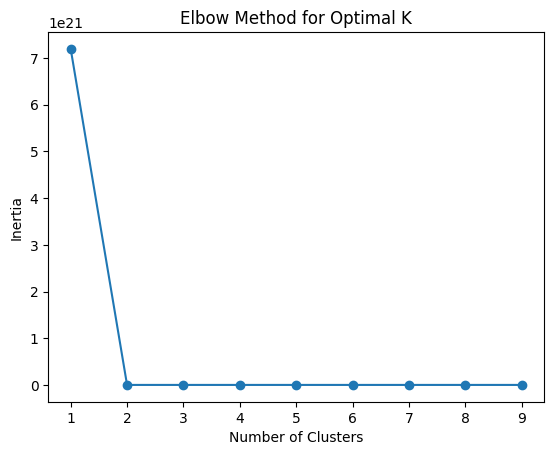

In [ ]:
# elbow method to find proper k amount
inertias = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_cluster_filtered)
    inertias.append(kmeans.inertia_)
plt.plot(range(1, 10), inertias, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [ ]:
# Standardize the features
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster_filtered)

In [ ]:
# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
open_food_facts.loc[X_cluster_filtered.index, 'cluster'] = kmeans.fit_predict(X_cluster_scaled)

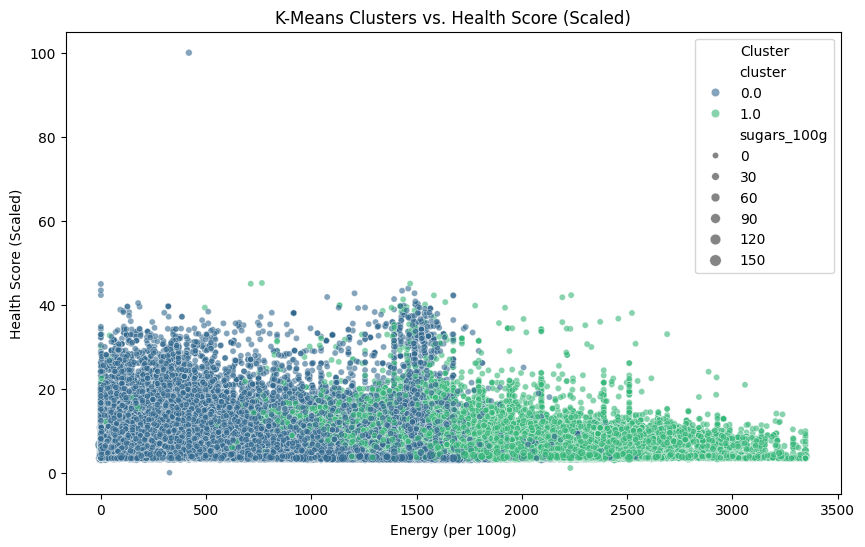

In [ ]:
# plot the clusters vs. health scores
plt.figure(figsize=(10, 6))
sns.scatterplot(x='energy_100g', y='health_score_scaled', hue='cluster', size='sugars_100g', data=open_food_facts.loc[X_cluster_filtered.index], palette='viridis', alpha=0.6)
plt.title('K-Means Clusters vs. Health Score (Scaled)')
plt.xlabel('Energy (per 100g)')
plt.ylabel('Health Score (Scaled)')
plt.legend(title='Cluster')
plt.show()

In [ ]:
# compare the cluster scores to our health score
cluster_health_comparison = pd.crosstab(open_food_facts['cluster'], open_food_facts['health_score_class'])
print("Cluster vs. Health Score Class Distribution:")
print(cluster_health_comparison)

Cluster vs. Health Score Class Distribution:
health_score_class      0      1      2
cluster                                
0.0                 68591  55730  64083
1.0                 23420  38586  30218


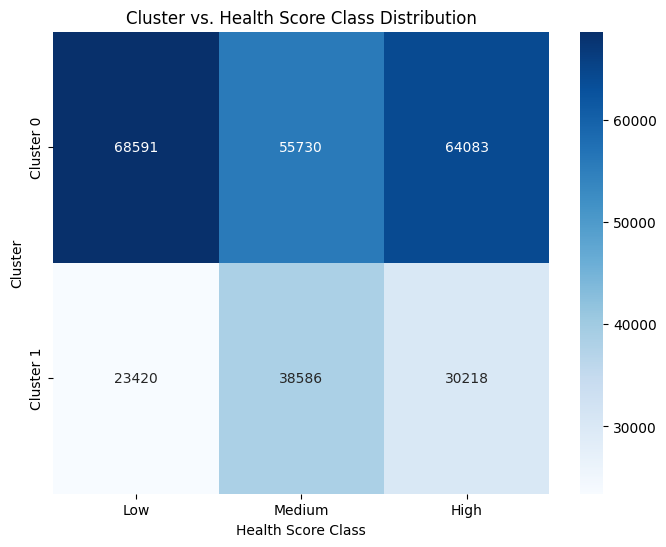

In [ ]:
# plot the comparison with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cluster_health_comparison, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Cluster 0', 'Cluster 1'])
plt.title('Cluster vs. Health Score Class Distribution')
plt.xlabel('Health Score Class')
plt.ylabel('Cluster')
plt.show()

In [ ]:
# Data Splitting

# [{X: Features}, {y: target}]
X = open_food_facts[features].copy()
y = open_food_facts['health_score_class']

# We will fill the missing values in X and Y
X = X.fillna(0)
y = y.fillna(0)

# Use standard 42 seed
seed = 42

# Set up the training and the testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = seed)

# Setup Scaler object
stdScaler = StandardScaler()

# Get the train and test scaled
X_trained_scaled = stdScaler.fit_transform(X_train)
X_test_scaled = stdScaler.transform(X_test)

# Make it into a DF
X_trained_scaled = pd.DataFrame(X_trained_scaled, columns = X_train.columns, index = X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns, index = X_test.index)

# Print the shape
print(f'Training Shape {X_trained_scaled.shape}')
print(f'Testing Shape {X_test_scaled.shape}')

Training Shape (226508, 13)
Testing Shape (56627, 13)


In [ ]:
# Import need lib(s) for the models used
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

In [ ]:
# Store the CF matricies
cf_matricies = {}

# test acc
acc_res = {}

# CV-mean and STD
cross_validation_res = {}

# As stated by the TA will use 3 models
# Model #1 Logicistic Regression
logistic_regression_model = LogisticRegression(
    max_iter = 1000,
    class_weight = 'balanced',
    random_state = seed
)

# Model #2 Random Forest
random_forest_model = RandomForestClassifier(
    n_estimators = 120,
    max_depth = 20,
    random_state = seed,
    class_weight = 'balanced'
)

# Model #3 Linear SVM
svm_model = LinearSVC (
    dual = 'auto',
    random_state = seed,
    class_weight = 'balanced'
)

# Use a dictionary K,V pair for name -> model
test_models = {'Logistic Regression': logistic_regression_model,
               'Random Forest' : random_forest_model,
               'SVM': svm_model}

In [ ]:
# Will use Cross valdation for each model below
from sklearn.model_selection import cross_val_score, KFold

Model Training, Evaluation, and Cross Validation

In [ ]:
# Loop over each model to train AND predict
for name in test_models:

  # Train the model on the training set
  test_models[name].fit(X_trained_scaled, y_train)

  # Get the y_pred on the test set
  y_pred = test_models[name].predict(X_test_scaled)

  # Get the current accuracy
  curr_acc = accuracy_score(y_test, y_pred)

  # Store the K,V pair in dict
  acc_res[name] = curr_acc

  # Do the cross validation
  curr_cross_validation = KFold(n_splits = 5, shuffle = True, random_state = seed)
  curr_cross_validation_scores = cross_val_score(test_models[name], X_trained_scaled, y_train, cv = curr_cross_validation, scoring = 'accuracy')

  # Get the mean and std of the cross validation
  cross_validation_std = curr_cross_validation_scores.std()
  cross_validation_mean = curr_cross_validation_scores.mean()

  # Append the mean and std as a tuple
  cross_validation_res[name] = (cross_validation_std, cross_validation_mean)

  # Now create the CF and append it to res
  cf_matrix = confusion_matrix(y_test, y_pred)
  cf_matricies[name] = cf_matrix

  # Print all details for visualization
  print(f'Current Model:{name}')
  print(f'Current Test accuracy: {curr_acc:.2f}')
  print(f'Cross Validation Std: {cross_validation_std:.2f}')
  print(f'Cross Validation Mean: {cross_validation_mean:.2f}')

  # Print the classifcaiton report
  print(classification_report(y_test, y_pred))

  # Print new lines for readability
  print('\n\n\n')

Current Model:Logistic Regression
Current Test accuracy: 0.59
Cross Validation Std: 0.01
Cross Validation Mean: 0.59
              precision    recall  f1-score   support

           0       0.60      0.64      0.62     18773
           1       0.52      0.32      0.39     18822
           2       0.61      0.80      0.69     19032

    accuracy                           0.59     56627
   macro avg       0.58      0.59      0.57     56627
weighted avg       0.58      0.59      0.57     56627





Current Model:Random Forest
Current Test accuracy: 0.86
Cross Validation Std: 0.00
Cross Validation Mean: 0.86
              precision    recall  f1-score   support

           0       0.89      0.89      0.89     18773
           1       0.81      0.81      0.81     18822
           2       0.88      0.88      0.88     19032

    accuracy                           0.86     56627
   macro avg       0.86      0.86      0.86     56627
weighted avg       0.86      0.86      0.86     56627





Cu

Building Model Evaluation Summaries

In [ ]:
# Start building the metrics
metrics = []
for name, model in test_models.items():

  # Get the y_pred
  y_pred = model.predict(X_test_scaled)

  # Get the accuracy
  accuracy = accuracy_score(y_test, y_pred)

  # Get the precision score
  precision = precision_score(y_test, y_pred, average = 'weighted')

  # Get the recall score
  recall = recall_score(y_test, y_pred, average = 'weighted')

  # Get the f1 score
  f1 = f1_score(y_test, y_pred, average = 'weighted')

  # Append the findings, need to keep it as a LIST of dicts in order to CONVERT
  # it to a DF later easier
  curr_dict = {}
  curr_dict['Model'] = name
  curr_dict['Accuracy'] = accuracy
  curr_dict['Precision'] = precision
  curr_dict['Recall'] = recall
  curr_dict['F1_Score'] = f1

  metrics.append(curr_dict)

# Convert to df
df_metrics = pd.DataFrame(metrics)

# Sort for consistency
df_metrics = df_metrics.sort_values(by = 'Accuracy', ascending = False)

Visualizing Model Comparison Metrics

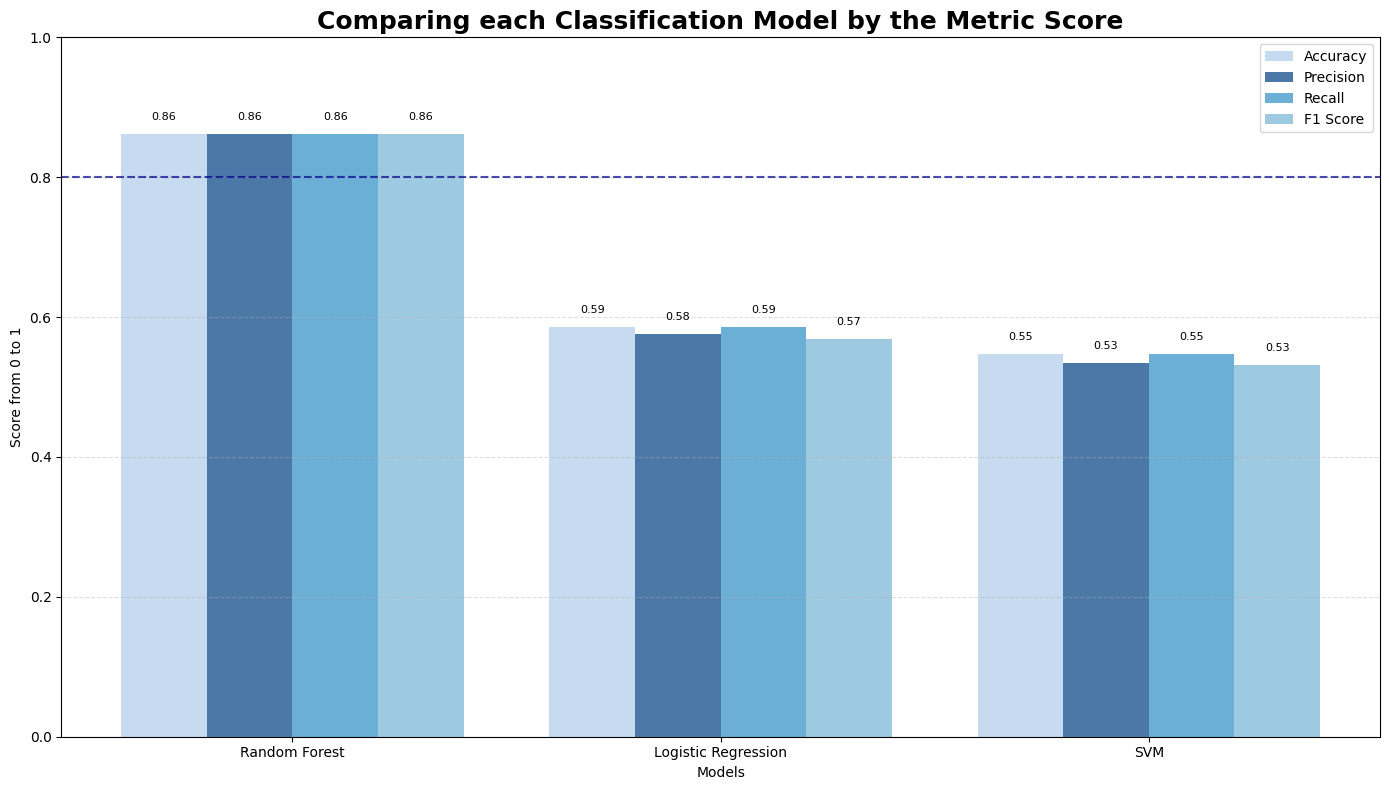

In [ ]:
# Visualizing the model
plt.figure(figsize = (14, 8))

colors = ['#4C78A8', '#6BAED6', '#9ECAE1', '#C6DBEF']

# Star with the x-axis
model_count = len(df_metrics)
x = np.arange(model_count)
w = min(0.2, (0.8 / 4))

# Plot the accuracy bar
plt.bar(x - w * 1.5,
        df_metrics['Accuracy'],
        w,
        label = 'Accuracy',
        color = '#C6DBEF',
        linewidth = .65)

# Plot the Precision Bar
plt.bar(x - w / 2,
        df_metrics['Precision'],
        w,
        label = 'Precision',
        color = '#4C78A8',
        linewidth = .65)

# Plot the Recall Bar
plt.bar(x + w / 2,
        df_metrics['Recall'],
        w,
        label = 'Recall',
        color = '#6BAED6',
        linewidth = .65)

# Plot the F1 Bar
plt.bar(x + w * 1.5,
        df_metrics['F1_Score'],
        w,
        label = 'F1_Score',
        color = '#9ECAE1',
        linewidth = .65)

plt.grid(axis = 'y',
         linestyle = '--',
         alpha = 0.4)

# Label the title
plt.title('Comparing each Classification Model by the Metric Score',
          fontsize = 18,
          fontweight = 'bold')

# Label x and y
plt.xlabel('Models')
plt.ylabel('Score from 0 to 1')

# Set the xticks
plt.xticks(ticks = x, labels = df_metrics['Model'])

# Y axis limit [0..1]
plt.ylim(0,1)

# Show the legened
plt.legend(['Accuracy', 'Precision', 'Recall', 'F1 Score'])

# Loop over each metric in df
for i, row in enumerate(df_metrics.itertuples()):

  # Get the position
  pos = i

  # Get each metric
  name = row.Model
  acc = row.Accuracy
  prec = row.Precision
  recall = row.Recall
  f1 = row.F1_Score

  # Accuracy Label
  Xpos_acc = pos - w * 1.5
  Ypos_acc = acc + 0.02
  plt.text(Xpos_acc,
           Ypos_acc,
           f'{acc:.2f}',
           ha = 'center',
           fontsize = 8)

  # Preciison Label
  Xpos_prec = pos - w / 2
  Ypos_prec = prec + 0.02
  plt.text(Xpos_prec,
           Ypos_prec,
           f'{prec:.2f}',
           ha = 'center',
           fontsize = 8)

  # Recall Label
  Xpos_rec = pos + w / 2
  Ypos_rec = recall + 0.02
  plt.text(Xpos_rec,
           Ypos_rec,
           f'{recall:.2f}',
           ha = 'center',
           fontsize = 8)

  # F1 Label
  Xpos_f1 = pos + w * 1.5
  Ypos_f1 = f1 + 0.02
  plt.text(Xpos_f1,
           Ypos_f1,
           f'{f1:.2f}',
           ha = 'center',
           fontsize = 8)

# Reference Line @0.8
plt.axhline(y = 0.8, color = '#00008B', linestyle = '--', alpha = 0.7)

# Wrap the plot
plt.box(True)

# Display
plt.tight_layout()
plt.show()

In [ ]:
# Print the metrics df
print(df_metrics.to_string(index = False))

              Model  Accuracy  Precision   Recall  F1_Score
      Random Forest  0.861956   0.861897 0.861956  0.861926
Logistic Regression  0.586540   0.575389 0.586540  0.568041
                SVM  0.546912   0.533938 0.546912  0.531974


Visualizing a Confusion Matrix for each Model

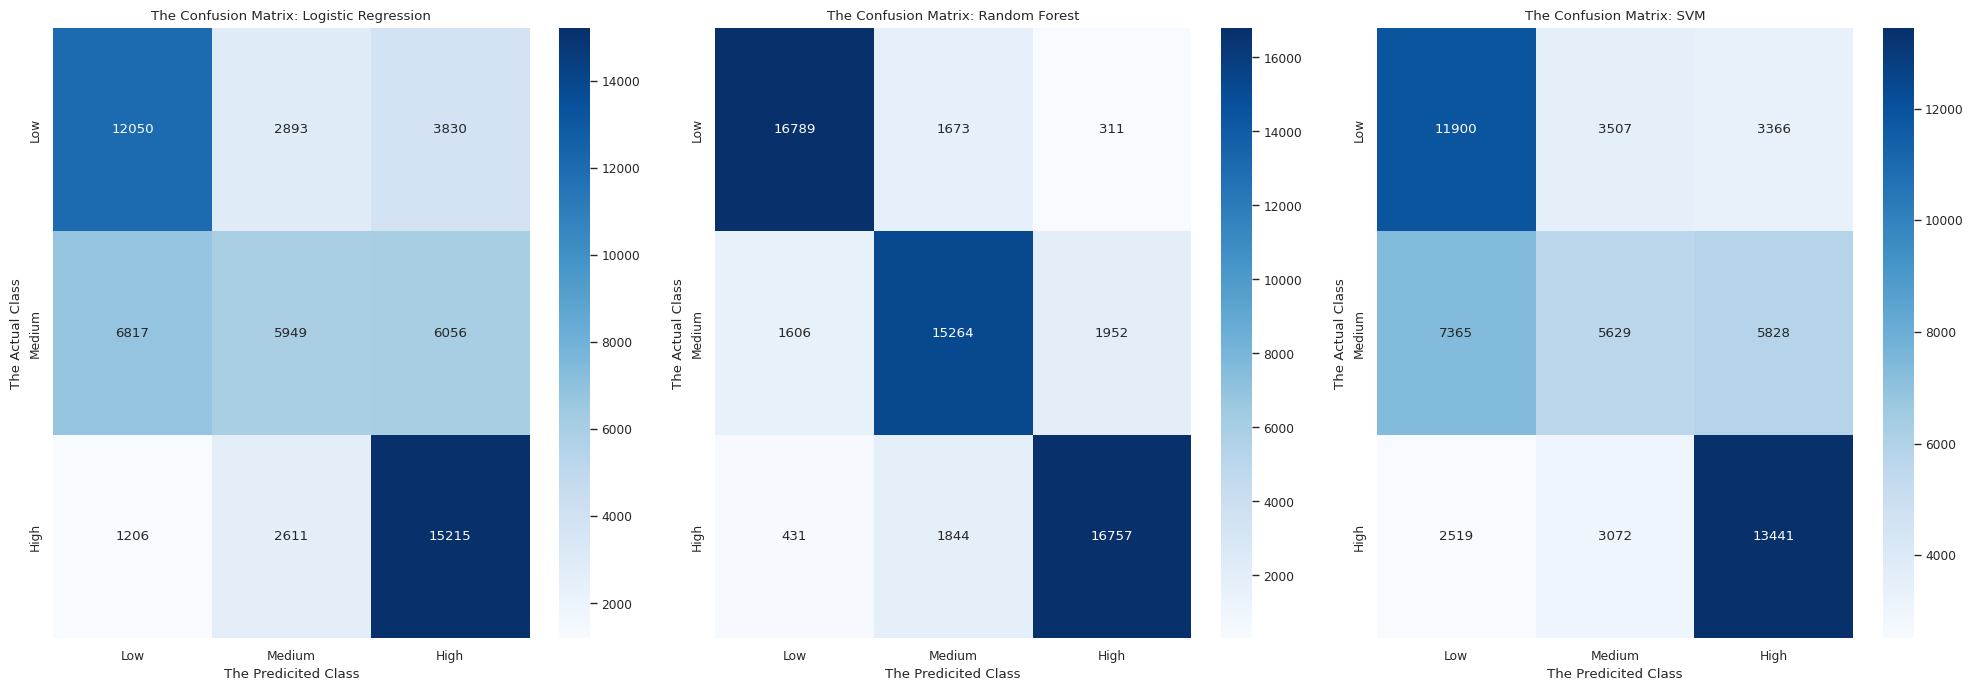

In [ ]:
# Make a side by side sub plots
plt.figure(figsize=(20, 7))

# Styling
sns.set_style('whitegrid')
sns.set_context('paper')

labels = ['Low', 'Medium', 'High']

# Create a subplot for each CF model
for i, name in enumerate(cf_matricies):

  # Get the matrix and plot
  curr_matrix = cf_matricies[name]
  plt.subplot(1, 3, i + 1)

  # For each cf make a corresponding heatmap
  sns.heatmap(curr_matrix,
              annot = True,
              fmt = 'd',
              cmap = 'Blues',
              xticklabels = labels,
              yticklabels = labels,
              )

  # Set the x and y label
  plt.xlabel('The Predicited Class')
  plt.ylabel('The Actual Class')

  # Set the title
  plt.title(f'The Confusion Matrix: {name}')

# Display
plt.tight_layout()
plt.show()

## Top 10 Most Important Features

<ipython-input-53-c0123a869938>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x = 'Importance',


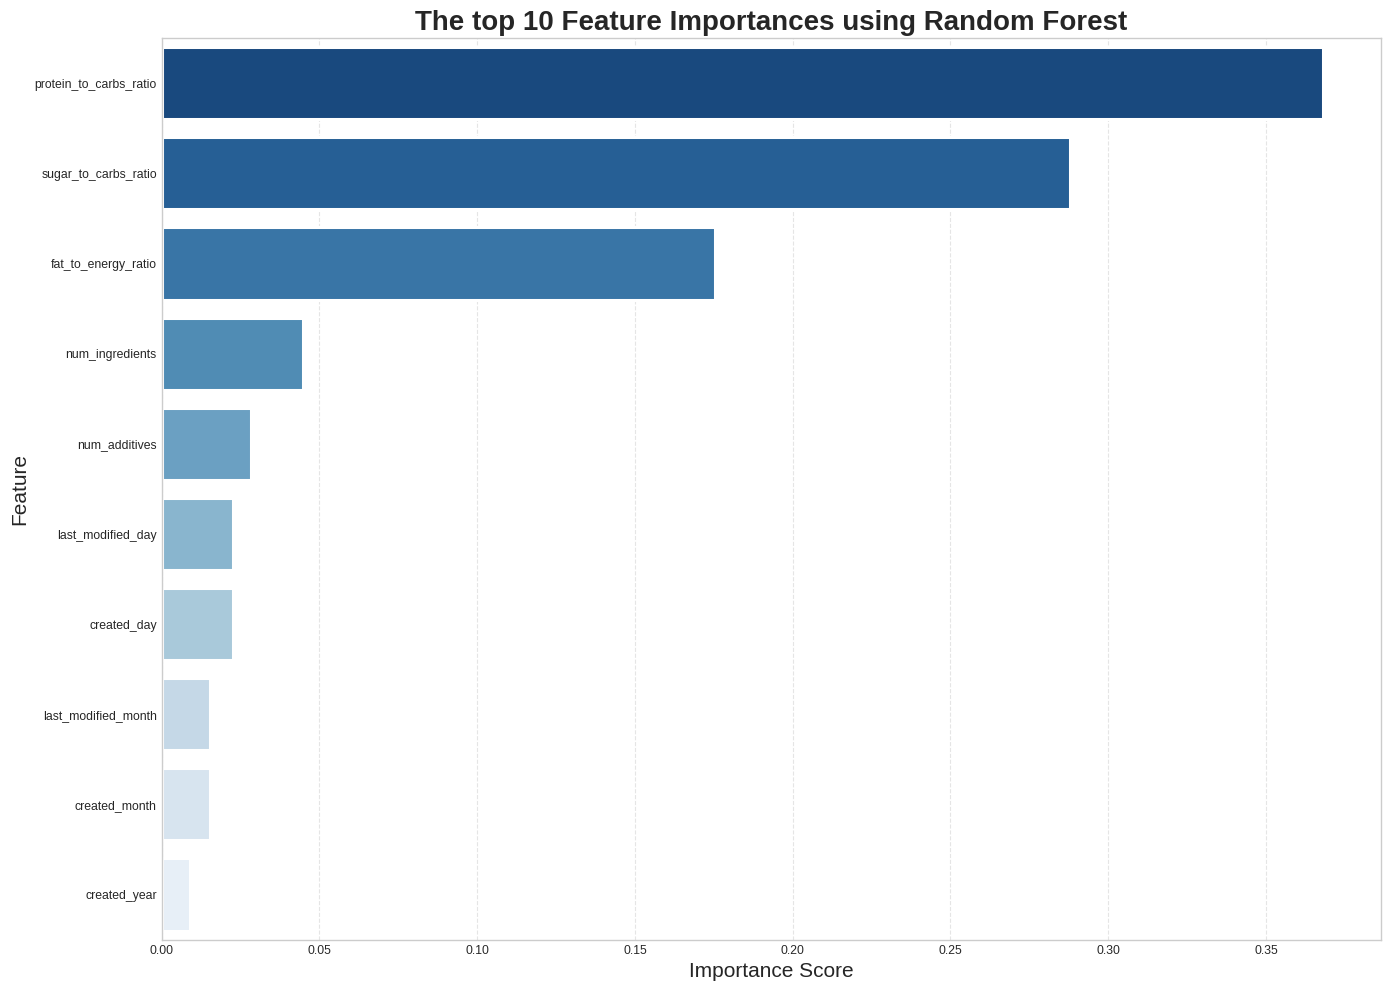

In [ ]:
# Top 10 Most Important features {Random Forest}
random_forest_model = test_models['Random Forest']
important_vals = random_forest_model.feature_importances_

# Create df
df_features = pd.DataFrame({'Feature': features, 'Importance': important_vals})

# Sort
df_features = df_features.sort_values(by = 'Importance', ascending = False)

# Top10 features
top10_features = df_features.head(10)

# Create figure and plot top 10
plt.figure(figsize = (14,10))
plt.style.use('seaborn-v0_8-whitegrid')
sns.barplot(x = 'Importance', y = 'Feature', data = df_features.head(10))

# Use a blue color scheme
colors = sns.color_palette("Blues_r", n_colors = len(top10_features))

barplot = sns.barplot(x = 'Importance',
                      y = 'Feature',
                      data = top10_features,
                      palette = colors,
                      edgecolor = 'white',
                      linewidth = 2.2)

# Set title
barplot.set_title('The top 10 Feature Importances using Random Forest',
                  fontsize = 20,
                  fontweight = 'bold')

# X and Y labels
barplot.set_xlabel('Importance Score', fontsize = 15)
barplot.set_ylabel('Feature', fontsize = 15)

# Better lines
barplot.xaxis.grid(True, linestyle='--', alpha=0.5)

# Display
plt.tight_layout()
plt.show()

## Final Results Summary and Practical Example


In [ ]:
# Organize final results into a summary
def generate_results_summary():
    summary = []

    # Classification Results
    summary.append("=== Classification Results ===")
    summary.append(df_metrics.to_string(index=False))
    summary.append("\nFeature Importances (Random Forest):")
    summary.append(top10_features.to_string(index=False))

    # Regression Results
    summary.append("\n=== Regression Results ===")
    summary.append(f"Mean Squared Error (MSE): {mse:.4f}")
    summary.append(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    summary.append(f"Mean Absolute Error (MAE): {mae:.4f}")
    summary.append(f"R-squared Score: {r2:.4f}")

    # Clustering Results
    summary.append("\n=== Clustering Results ===")
    summary.append("Cluster vs. Health Score Class Distribution:")
    summary.append(cluster_health_comparison.to_string())

    return "\n".join(summary)


print("Results Summary:")
print(generate_results_summary())




Results Summary:
=== Classification Results ===
              Model  Accuracy  Precision   Recall  F1_Score
      Random Forest  0.861956   0.861897 0.861956  0.861926
Logistic Regression  0.586540   0.575389 0.586540  0.568041
                SVM  0.546912   0.533938 0.546912  0.531974

Feature Importances (Random Forest):
               Feature  Importance
protein_to_carbs_ratio    0.368132
  sugar_to_carbs_ratio    0.287760
   fat_to_energy_ratio    0.175374
       num_ingredients    0.044877
         num_additives    0.028201
     last_modified_day    0.022485
           created_day    0.022456
   last_modified_month    0.015362
         created_month    0.015334
          created_year    0.008891

=== Regression Results ===
Mean Squared Error (MSE): 3.3406
Root Mean Squared Error (RMSE): 1.8277
Mean Absolute Error (MAE): 0.7500
R-squared Score: 0.7786

=== Clustering Results ===
Cluster vs. Health Score Class Distribution:
health_score_class      0      1      2
cluster           

In [ ]:
# Practical Example: Predict health score class for a sample food product
def predict_food_health(product_data, model, scaler, features):
    # Convert product data to DataFrame
    product_df = pd.DataFrame([product_data])

    # Ensure all required features are present
    for feature in features:
        if feature not in product_df.columns:
            product_df[feature] = 0

    # Select and scale features
    X_product = product_df[features]
    X_product = X_product.fillna(0)
    X_product_scaled = scaler.transform(X_product)

    # Predict health score class
    prediction = model.predict(X_product_scaled)[0]
    class_labels = {0: "Low", 1: "Medium", 2: "High"}
    predicted_class = class_labels[prediction]

    return predicted_class, X_product



In [ ]:
# Sample food product: Whole Grain Cereal Bar
sample_product = {
    'num_ingredients': 8,
    'fat_100g': 10.0,
    'energy_100g': 400.0,
    'sugars_100g': 15.0,
    'carbohydrates_100g': 60.0,
    'proteins_100g': 8.0,
    'num_additives': 2,
    'has_palm_oils': 0,
    'has_possible_palm_oils': 1,
    'created_year': 2023,
    'created_month': 6,
    'created_day': 15,
    'last_modified_year': 2023,
    'last_modified_month': 6,
    'last_modified_day': 15,
}

In [ ]:
# Calculate derived features
sample_product['fat_to_energy_ratio'] = sample_product['fat_100g'] / sample_product['energy_100g']
sample_product['sugar_to_carbs_ratio'] = sample_product['sugars_100g'] / sample_product['carbohydrates_100g']
sample_product['protein_to_carbs_ratio'] = sample_product['proteins_100g'] / sample_product['carbohydrates_100g']

# Predict health score class
predicted_class, input_features = predict_food_health(sample_product, random_forest_model, stdScaler, features)

# Display practical example results
print("\n=== Practical Example: Whole Grain Cereal Bar ===")
print("Input Features:")
for feature, value in input_features.iloc[0].items():
    print(f"{feature}: {value:.4f}" if isinstance(value, float) else f"{feature}: {value}")
print(f"\nPredicted Health Score Class: {predicted_class}")
print("Interpretation: This cereal bar is classified as having a", predicted_class.lower(),
      "health score, indicating",
      {"Low": "higher levels of unhealthy nutrients relative to healthy ones.",
       "Medium": "a balanced mix of healthy and unhealthy nutrients.",
       "High": "a favorable ratio of healthy to unhealthy nutrients."}[predicted_class])



=== Practical Example: Whole Grain Cereal Bar ===
Input Features:
num_ingredients: 8.0000
fat_to_energy_ratio: 0.0250
sugar_to_carbs_ratio: 0.2500
protein_to_carbs_ratio: 0.1333
num_additives: 2.0000
has_palm_oils: 0.0000
has_possible_palm_oils: 1.0000
created_year: 2023.0000
created_month: 6.0000
created_day: 15.0000
last_modified_year: 2023.0000
last_modified_month: 6.0000
last_modified_day: 15.0000

Predicted Health Score Class: Medium
Interpretation: This cereal bar is classified as having a medium health score, indicating a balanced mix of healthy and unhealthy nutrients.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


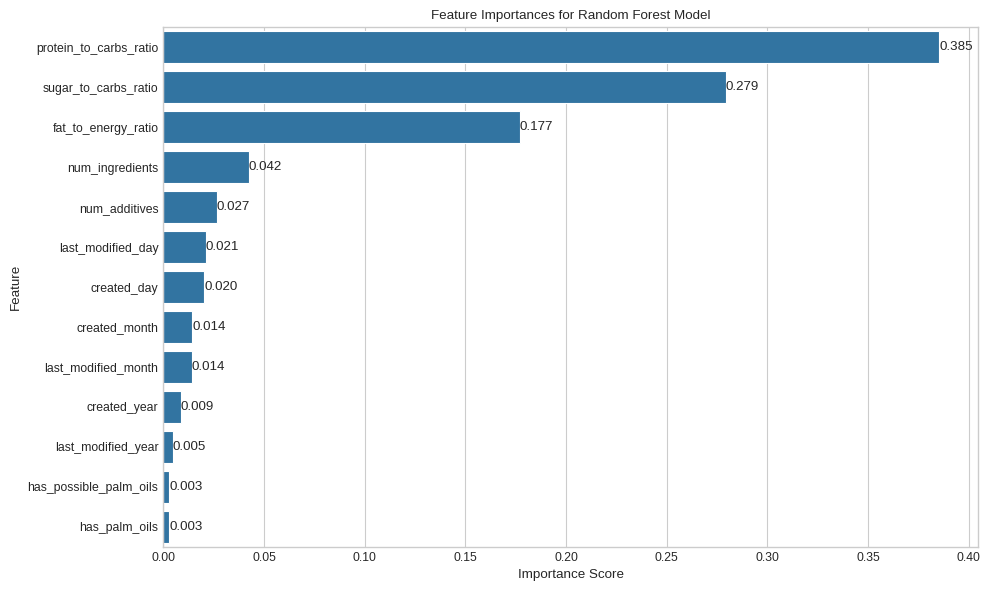

In [ ]:
# Visualize feature importance for the sample product
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title('Feature Importances for Random Forest Model')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
for i, v in enumerate(feature_importances['Importance']):
    plt.text(v, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.show()

Hyperparameter Tuning for Random Forest

In [ ]:
# Defines the parameter grid

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'max_features': ['sqrt']
}

In [ ]:
# Run GridSearchCV hyperparameter tuning with 3-fold CV
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import time

rf = RandomForestClassifier(class_weight='balanced', random_state=seed)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1
)
start_time = time.time()
grid_search.fit(X_trained_scaled, y_train)
tuning_time = time.time() - start_time
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_
print(f"Best Parameters: {best_params}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}")
print(f"Tuning Time: {tuning_time:.2f} seconds")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best Cross-Validation Accuracy: 0.8609
Tuning Time: 396.83 seconds


In [ ]:
# Evaluate Tuned Model by test set metrics

y_pred = best_model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average='weighted')
test_recall = recall_score(y_test, y_pred, average='weighted')
test_f1 = f1_score(y_test, y_pred, average='weighted')
cm = confusion_matrix(y_test, y_pred)
acc_res['Random Forest'] = test_accuracy
cf_matricies['Random Forest'] = cm
cross_validation_res['Random Forest'] = (grid_search.cv_results_['std_test_score'][grid_search.best_index_], best_score)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")


Test Accuracy: 0.8654
Test Precision: 0.8651
Test Recall: 0.8654
Test F1-Score: 0.8652


<ipython-input-62-575e1af789f0>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='mean_test_score', y=top_results.index, data=top_results, palette='Blues_r')


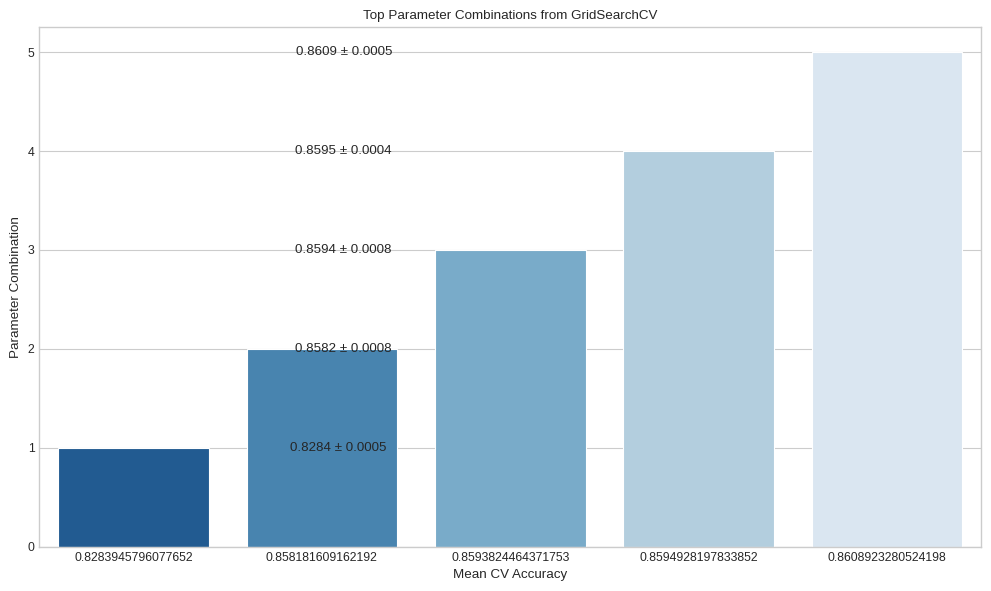

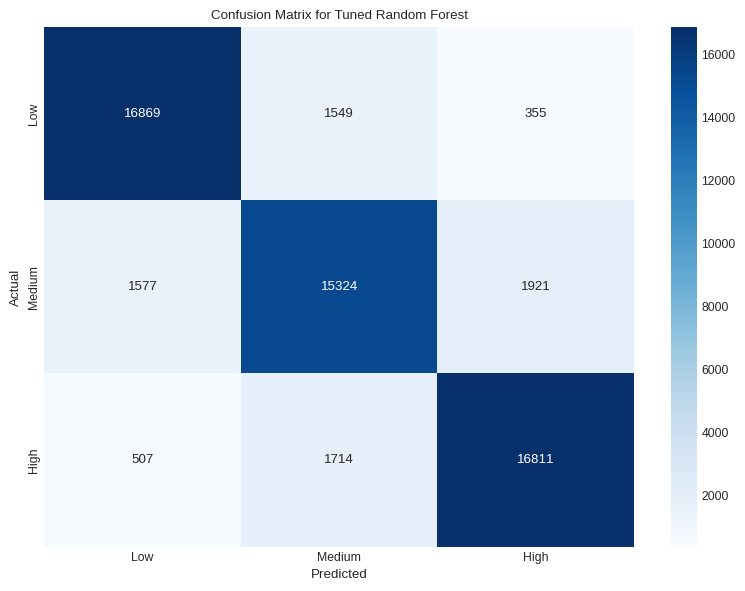

In [ ]:
# Visualize Results

results = pd.DataFrame(grid_search.cv_results_)
top_results = results[['params', 'mean_test_score', 'std_test_score']].sort_values(by='mean_test_score', ascending=False).head(5)
plt.figure(figsize=(10, 6))
sns.barplot(x='mean_test_score', y=top_results.index, data=top_results, palette='Blues_r')
plt.title('Top Parameter Combinations from GridSearchCV')
plt.xlabel('Mean CV Accuracy')
plt.ylabel('Parameter Combination')

for i, row in top_results.iterrows():
    plt.text(row['mean_test_score'], i, f"{row['mean_test_score']:.4f} ± {row['std_test_score']:.4f}", va='center')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix for Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()